# 📊 Statistische Analyse & Visualisierung — Immobilienpreise Niedersachsen
**Agiles Programmierprojekt – intoCODE / InterGeeks**

Dieses Notebook deckt alle Pflichtbereiche der Aufgabendefinition ab:
1. Datenbereinigung & Datenqualität
2. Deskriptive Statistik und Datenverständnis
3. Einflussanalyse
4. Zusammenhangsanalyse
5. Hypothesentests und Inferenzstatistik

---
> **Hinweis zu Data Leakage:** `obj_purchasePrice_per_qm` ist direkt aus der Zielvariable berechnet (Preis / Fläche) → darf **nicht** als Feature im ML verwendet werden. Sie wird hier nur für die deskriptive Analyse genutzt.

## 0. Imports & Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import sqlite3
import warnings
warnings.filterwarnings("ignore")

# ── Globaler Plot-Stil ──────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

# ── Output-Ordner für Präsentationsgrafiken ─────────────────────────────────
OUTPUT_DIR = "plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_fig(fig, name):
    """Speichert Grafik als PNG (150 dpi) für PowerPoint-Export."""
    fig.savefig(f"{OUTPUT_DIR}/{name}.png", dpi=150, bbox_inches="tight")
    print(f"  💾 Gespeichert: {OUTPUT_DIR}/{name}.png")

print("✅ Setup abgeschlossen.")

✅ Setup abgeschlossen.


---
## 1. Daten laden
Die Daten werden aus der MySQL/SQLite-Datenbank geladen.
Stelle sicher, dass `../data/db/prices.db` erreichbar ist.

In [2]:
# ── Dynamischer DB-Pfad (passt sich automatisch an die Ordnertiefe an) ───────
current_dir = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
db_filename = os.path.normpath(os.path.join(current_dir, "../data/db/prices.db"))
table_name  = "house_prices"

print(f"🗄️  Verbinde mit Datenbank: {db_filename}")

conn   = sqlite3.connect(db_filename)
df_raw = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
conn.close()

print(f"✅ Daten geladen! Rohdaten-Shape: {df_raw.shape}")
df_raw.head()

🗄️  Verbinde mit Datenbank: c:\Users\Yasser Nourallah\Desktop\HSH Weiterbildung\Abschluss Projekt\hoky_immobilien\data\db\prices.db
✅ Daten geladen! Rohdaten-Shape: (5055, 20)


,obj_regio1,obj_newlyConst,obj_yearConstructed,obj_firingTypes,obj_cellar,obj_houseNumber,obj_livingSpace,geo_krs,obj_condition,obj_street,geo_plz,obj_noRooms,obj_telekomInternetProductAvailable,obj_barrierFree,obj_regio3,obj_livingSpaceRange,obj_telekomUploadSpeed,obj_telekomDownloadSpeed,obj_purchasePrice,obj_purchasePrice_per_qm
0,Niedersachsen,n,2013.0,gas,n,NaN,170.0,Verden_Kreis,well_kept,NaN,28832.0,6.0,1.0,n,Achim,5.0,40.0,100.0,549000.0,3229.411765
1,Niedersachsen,n,1909.0,oil,n,NaN,170.0,Hannover_Kreis,well_kept,NaN,30900.0,6.0,1.0,n,Wedemark,5.0,2.4,16.0,460000.0,2705.882353
2,Niedersachsen,n,1969.0,district_heating,y,NaN,116.0,Celle_Kreis,well_kept,NaN,29353.0,6.0,1.0,n,other,2.0,10.0,50.0,148500.0,1280.172414
3,Niedersachsen,y,2020.0,NaN,n,NaN,133.0,Helmstedt_Kreis,first_time_use,NaN,38364.0,4.0,1.0,n,Schöningen,3.0,40.0,100.0,248400.0,1867.669173
4,Niedersachsen,n,2000.0,district_heating,y,NaN,136.0,Wolfsburg,well_kept,NaN,38446.0,5.0,1.0,y,other,3.0,2.4,16.0,369000.0,2713.235294


---
## 2. Datenbereinigung & Datenqualitätsbewertung
*(Aufgabendefinition: Identifikation von Ausreißern und fehlenden Werten, Bewertung der Datenqualität)*

### 2.1 Fehlende Werte analysieren

🔍 Fehlende Werte je Spalte:
                                     fehlend  prozent (%)
obj_street                              4583         90.7
obj_houseNumber                         4583         90.7
obj_condition                           1558         30.8
obj_telekomDownloadSpeed                 983         19.4
obj_telekomUploadSpeed                   983         19.4
obj_firingTypes                          799         15.8
obj_telekomInternetProductAvailable      326          6.4
  💾 Gespeichert: plots/01_fehlende_werte.png


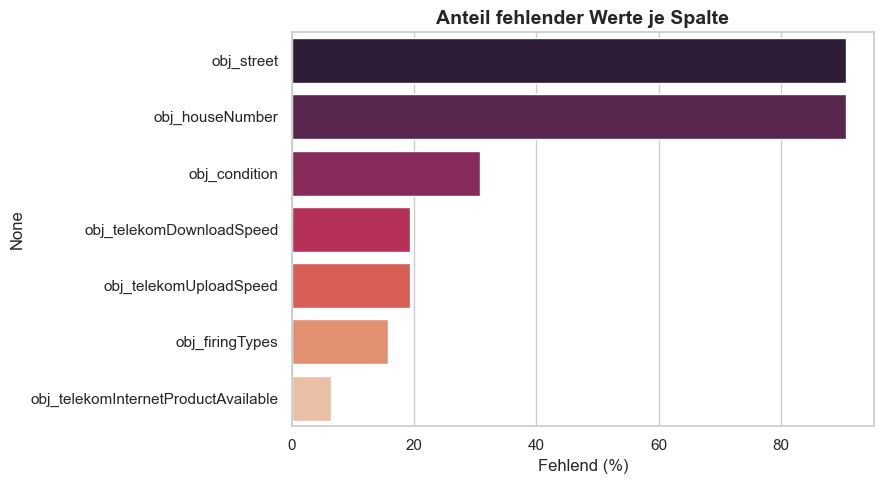

In [3]:
missing     = df_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_table = pd.DataFrame({"fehlend": missing, "prozent (%)": missing_pct})
missing_table = missing_table[missing_table["fehlend"] > 0]

print("🔍 Fehlende Werte je Spalte:")
print(missing_table)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=missing_table["prozent (%)"], y=missing_table.index,
            hue=missing_table.index, ax=ax, palette="rocket", legend=False)
ax.set_title("Anteil fehlender Werte je Spalte")
ax.set_xlabel("Fehlend (%)")
plt.tight_layout()
save_fig(fig, "01_fehlende_werte")
plt.show()

**Entscheidungen zu fehlenden Werten:**
- `obj_houseNumber`, `obj_street`, `obj_regio1`: >90% fehlend oder konstant → **entfernen**
- `obj_firingTypes`, `obj_condition`: fehlend → Kategorie **„unknown"** (keine Daten ≠ keine Heizung)
- `obj_telekomUploadSpeed`, `obj_telekomDownloadSpeed`: fehlend → **0** + Flag-Spalte `obj_hasInternetData`

### 2.2 Bereinigung durchführen

In [4]:
df = df_raw.copy()

# ── Konstante / nicht-informative Spalten entfernen ─────────────────────────
df = df.drop(columns=["obj_regio1"], errors="ignore")
# obj_regio1 ist für alle 5055 Zeilen = "Niedersachsen" → kein Informationsgewinn

# ── Adressspalten entfernen (>90 % fehlend, nicht für ML relevant) ──────────
df = df.drop(columns=["obj_houseNumber", "obj_street"], errors="ignore")

# ── Unplausible Zeilen entfernen ─────────────────────────────────────────────
n = len(df)
df = df[df["obj_livingSpace"] > 0]       # livingSpace=0 → erzeugt inf bei price/m²
df = df[df["obj_purchasePrice"] >= 5000] # Preise unter 5000€ → Dateneingabefehler
print(f"Entfernte Zeilen: {n - len(df)}  (livingSpace=0 oder Preis < 5000 €)")

# ── Kategoriale fehlende Werte auffüllen ────────────────────────────────────
df["obj_firingTypes"] = df["obj_firingTypes"].fillna("unknown")
df["obj_condition"]   = df["obj_condition"].fillna("unknown")
df["obj_telekomInternetProductAvailable"] = (
    df["obj_telekomInternetProductAvailable"].fillna("unknown").astype(str)
)

# ── Numerische fehlende Werte (Internet-Geschwindigkeit) ────────────────────
df["obj_hasInternetData"]        = df["obj_telekomUploadSpeed"].notna().astype(int)
df["obj_telekomUploadSpeed"]     = df["obj_telekomUploadSpeed"].fillna(0)
df["obj_telekomDownloadSpeed"]   = df["obj_telekomDownloadSpeed"].fillna(0)

# ── Heizungstypen von 60 → 7 Gruppen zusammenfassen ────────────────────────
def group_firing_type(val):
    v = str(val).lower()
    if v == "unknown": return "unknown"
    if "gas"           in v: return "gas"
    if "oil"           in v: return "oil"
    if "district"      in v or "local_heating" in v: return "fernwaerme"
    if any(x in v for x in ["solar","geotherm","environmental","pellet","wood"]): return "erneuerbar"
    if "electricity"   in v: return "strom"
    return "sonstige"

df["firingType_grouped"] = df["obj_firingTypes"].apply(group_firing_type)

print(f"\n✅ Bereinigte Shape: {df.shape}")
print(f"\nVerbleibende fehlende Werte: {df.isnull().sum().sum()}")
print(df["firingType_grouped"].value_counts())

Entfernte Zeilen: 23  (livingSpace=0 oder Preis < 5000 €)

✅ Bereinigte Shape: (5032, 19)

Verbleibende fehlende Werte: 0
firingType_grouped
gas           3034
oil            850
unknown        797
strom          138
erneuerbar     135
fernwaerme      69
sonstige         9
Name: count, dtype: int64


### 2.3 Ausreißer-Bereinigung nach Quantilen (je Landkreis)

✅ Shape nach Ausreißer-Bereinigung: (4900, 19)
  💾 Gespeichert: plots/00_outlier_clean_check.png


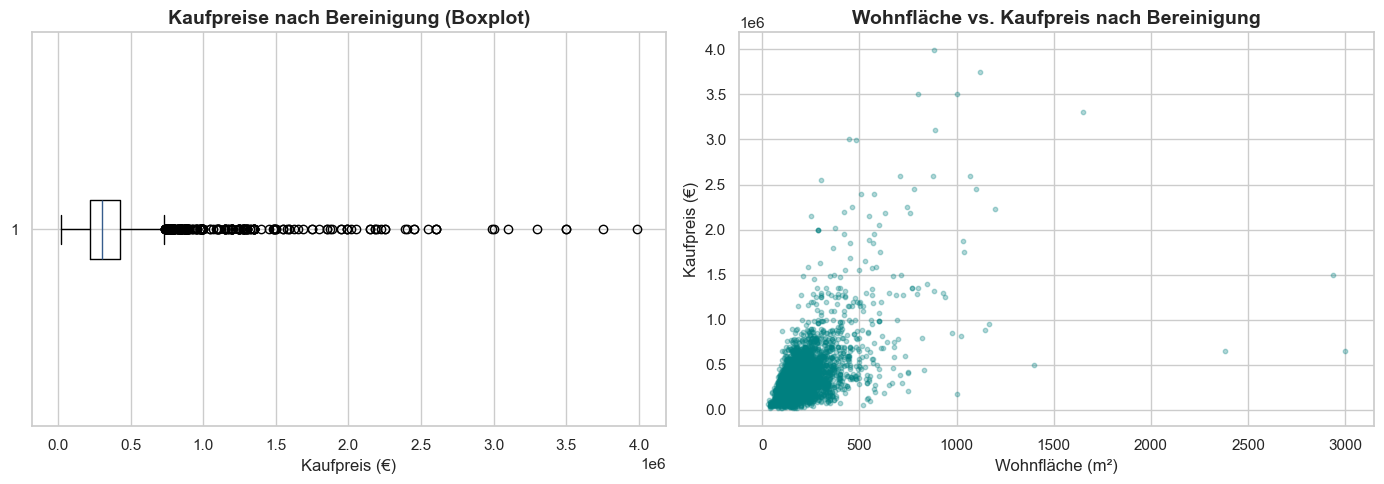

💾 Gespeichert: price_cleaned_for_analysis.csv


In [ ]:
    def remove_outliers_by_quantile(df, col="obj_purchasePrice_per_qm",
                                lower_pct=0.01, upper_pct=0.99, group_col="geo_krs"):
        """Entfernt die extremsten 1% nach oben und unten – getrennt je Landkreis."""
        parts = []
        for _, sub in df.groupby(group_col):
            lo = sub[col].quantile(lower_pct)
            hi = sub[col].quantile(upper_pct)
            parts.append(sub[(sub[col] >= lo) & (sub[col] <= hi)])
        return pd.concat(parts)

    df = remove_outliers_by_quantile(df)
    print(f"✅ Shape nach Ausreißer-Bereinigung: {df.shape}")

    # Visuelle Bestätigung: Box- und Streudiagramm nach der Bereinigung
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.boxplot(df["obj_purchasePrice"], vert=False)
    ax1.set_title("Kaufpreise nach Bereinigung (Boxplot)")
    ax1.set_xlabel("Kaufpreis (€)")

    ax2.scatter(df["obj_livingSpace"], df["obj_purchasePrice"], alpha=0.3, color="teal", s=10)
    ax2.set_title("Wohnfläche vs. Kaufpreis nach Bereinigung")
    ax2.set_xlabel("Wohnfläche (m²)")
    ax2.set_ylabel("Kaufpreis (€)")
    plt.tight_layout()
    save_fig(fig, "00_outlier_clean_check")
    plt.show()

    # Bereinigte Daten speichern (für ML-Notebooks weiterverwendbar)
    df.to_csv("price_cleaned_for_analysis.csv", index=False)
    print("💾 Gespeichert: price_cleaned_for_analysis.csv")

---
## 3. Deskriptive Statistik und Datenverständnis
*(Aufgabendefinition: Berechnung von Lage- und Streuungsmaßen, Analyse der Verteilungen, Erstellung geeigneter Visualisierungen)*

### 3.1 Lage- und Streuungsmaße (Lageparameter & Streuungsmaße)

In [6]:
LEAKAGE_COL = "obj_purchasePrice_per_qm"  # nur für deskriptive Analyse, NICHT als ML-Feature!
numeric_cols = [
    "obj_purchasePrice",
    LEAKAGE_COL,
    "obj_livingSpace",
    "obj_noRooms",
    "obj_yearConstructed",
]

desc = df[numeric_cols].describe().T
desc["median"]   = df[numeric_cols].median()
desc["variance"] = df[numeric_cols].var()
desc["IQR"]      = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
desc["skewness"] = df[numeric_cols].skew()   # Schiefe: >0 = rechtsschief

print("📊 Lage- und Streuungsmaße (Überblick):")
print(desc[["mean","median","std","variance","IQR","min","max","skewness"]].round(2).to_string())

📊 Lage- und Streuungsmaße (Überblick):
                               mean     median        std      variance        IQR       min         max  skewness
obj_purchasePrice         363660.11  305000.00  280196.33  7.850998e+10  206000.00  18000.00  3990000.00      4.55
obj_purchasePrice_per_qm    1984.89    1894.74     946.66  8.961716e+05    1248.69     96.52     8578.43      0.92
obj_livingSpace              195.32     161.65     132.15  1.746426e+04     101.00     30.00     3000.00      6.94
obj_noRooms                    6.64       6.00       3.83  1.464000e+01       4.00      1.00      100.00      5.54
obj_yearConstructed         1964.70    1973.00      53.44  2.855630e+03      46.00   1496.00     2021.00     -2.69


### 3.2 Verteilung der Zielvariable Kaufpreis

  💾 Gespeichert: plots/02_verteilung_kaufpreis.png


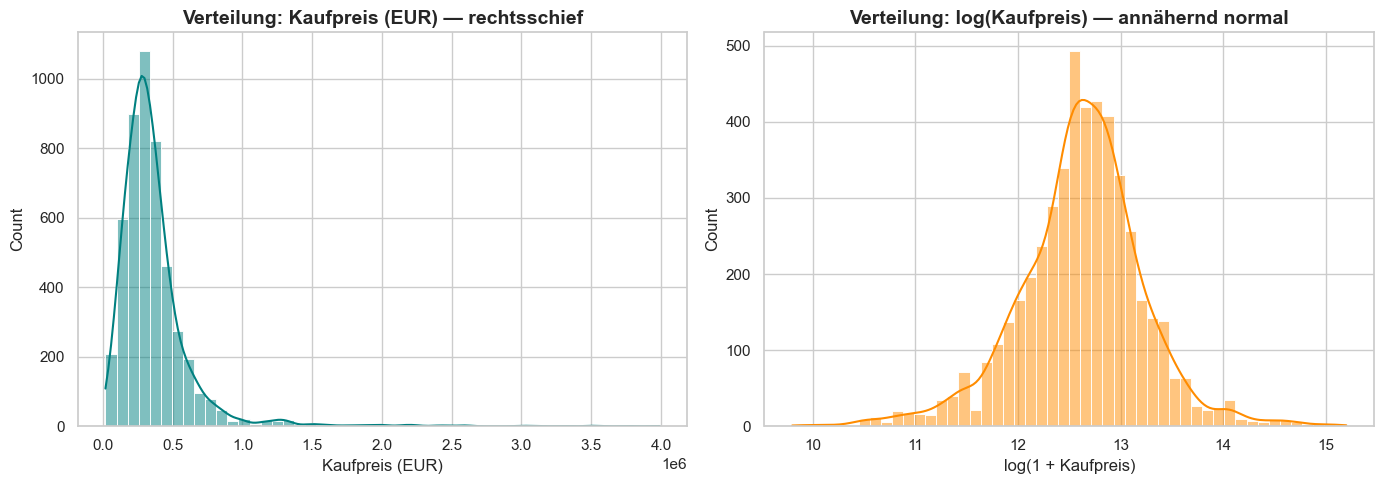

Schiefe Original:        4.55
Schiefe log-transformiert: -0.24
→ Log-Transformation empfohlen für lineare Modelle!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["obj_purchasePrice"], bins=50, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Verteilung: Kaufpreis (EUR) — rechtsschief")
axes[0].set_xlabel("Kaufpreis (EUR)")

sns.histplot(np.log1p(df["obj_purchasePrice"]), bins=50, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Verteilung: log(Kaufpreis) — annähernd normal")
axes[1].set_xlabel("log(1 + Kaufpreis)")

plt.tight_layout()
save_fig(fig, "02_verteilung_kaufpreis")
plt.show()

print(f"Schiefe Original:        {df['obj_purchasePrice'].skew():.2f}")
print(f"Schiefe log-transformiert: {np.log1p(df['obj_purchasePrice']).skew():.2f}")
print("→ Log-Transformation empfohlen für lineare Modelle!")

### 3.3 Verteilung weiterer numerischer Variablen

  💾 Gespeichert: plots/03_verteilungen_uebersicht.png


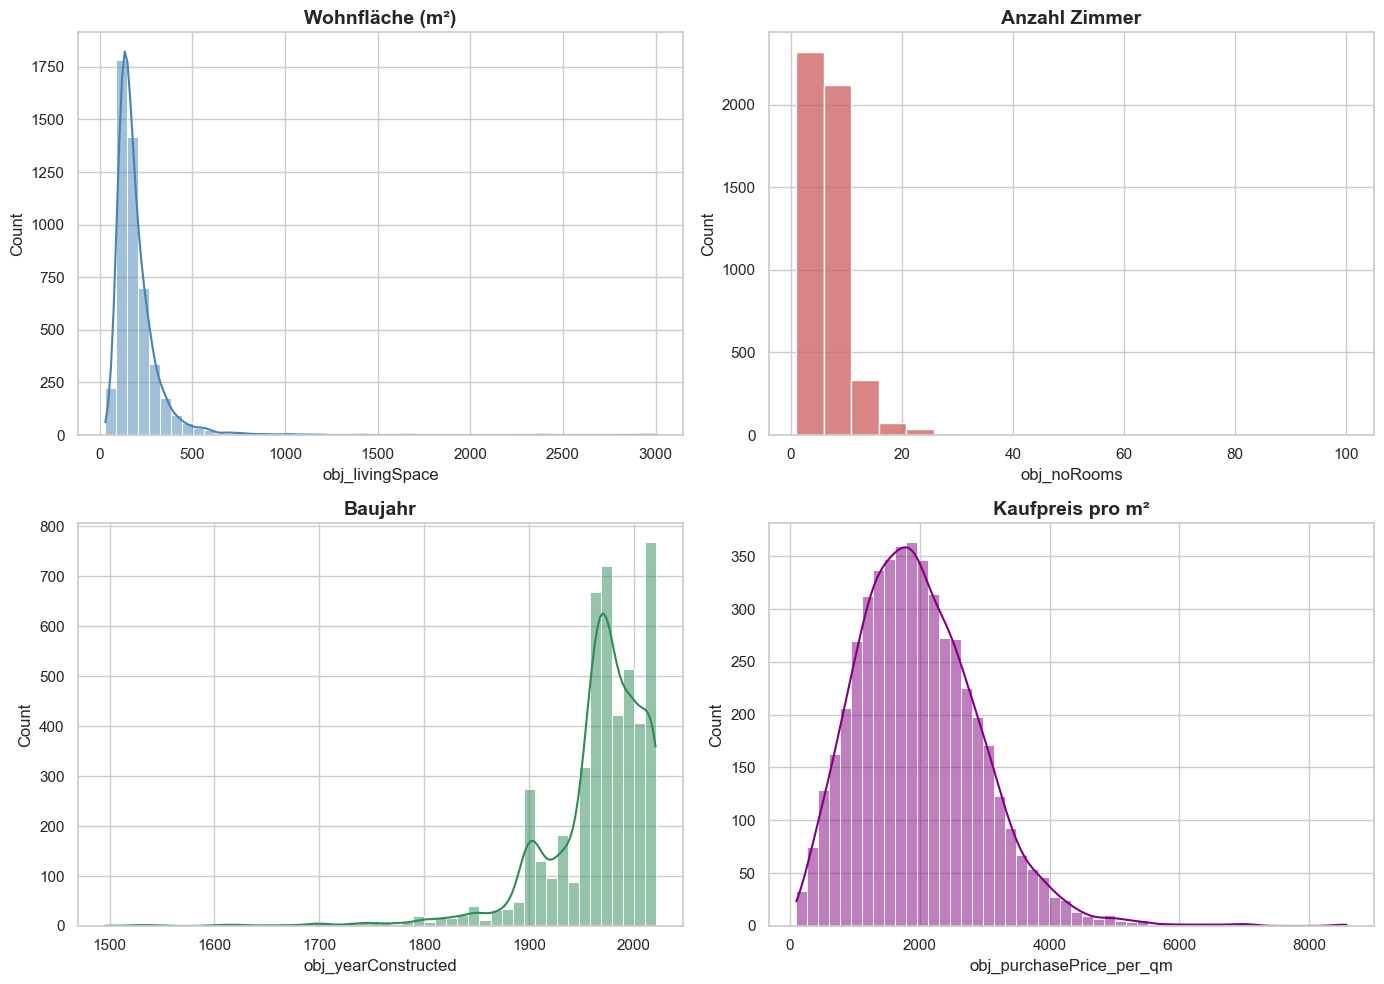

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df["obj_livingSpace"],      bins=50, kde=True, ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Wohnfläche (m²)")

sns.histplot(df["obj_noRooms"],          bins=20, kde=False, ax=axes[0,1], color="indianred")
axes[0,1].set_title("Anzahl Zimmer")

sns.histplot(df["obj_yearConstructed"],  bins=50, kde=True, ax=axes[1,0], color="seagreen")
axes[1,0].set_title("Baujahr")

sns.histplot(df[LEAKAGE_COL],           bins=50, kde=True, ax=axes[1,1], color="purple")
axes[1,1].set_title("Kaufpreis pro m²")

plt.tight_layout()
save_fig(fig, "03_verteilungen_uebersicht")
plt.show()

### 3.4 Ausreißer-Identifikation (1.5 × IQR Regel)

  💾 Gespeichert: plots/04_boxplots_ausreisser.png


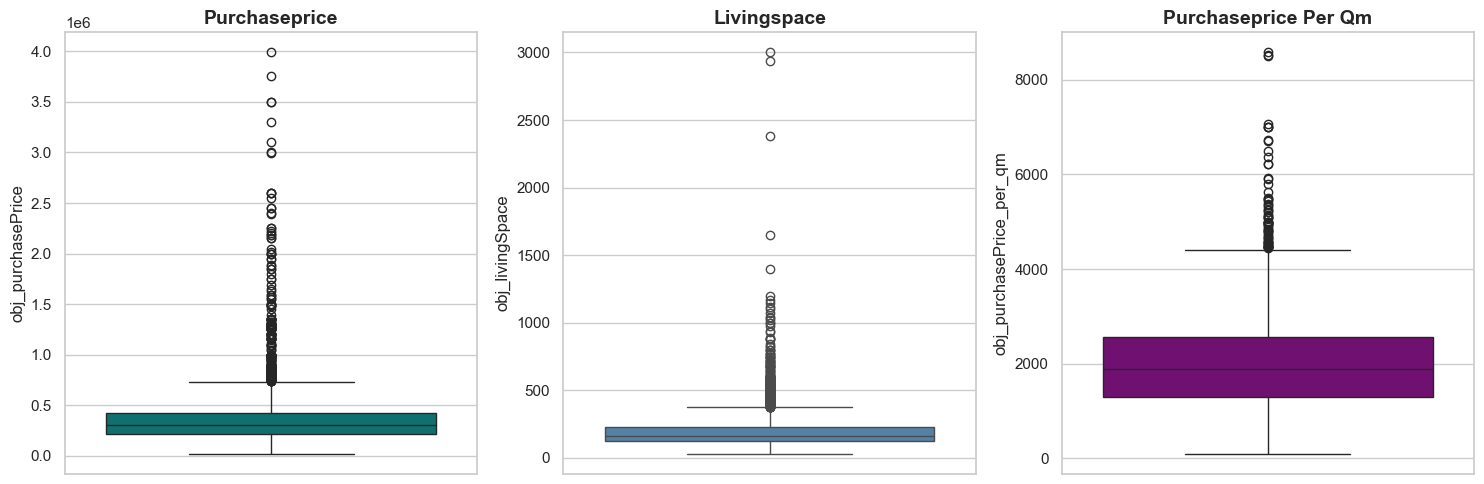

🚨 Ausreißer nach 1.5×IQR-Regel:
  obj_purchasePrice                  :  278 Ausreißer (5.7%)
  obj_livingSpace                    :  276 Ausreißer (5.6%)
  obj_purchasePrice_per_qm           :   65 Ausreißer (1.3%)
  obj_noRooms                        :  175 Ausreißer (3.6%)


In [9]:
# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, color in zip(axes,
        ["obj_purchasePrice","obj_livingSpace", LEAKAGE_COL],
        ["teal","steelblue","purple"]):
    sns.boxplot(y=df[col], ax=ax, color=color)
    ax.set_title(col.replace("obj_","").replace("_"," ").title())
plt.tight_layout()
save_fig(fig, "04_boxplots_ausreisser")
plt.show()

# Numerische Auswertung
print("🚨 Ausreißer nach 1.5×IQR-Regel:")
for col in ["obj_purchasePrice","obj_livingSpace", LEAKAGE_COL,"obj_noRooms"]:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR    = Q3 - Q1
    n_out  = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    print(f"  {col:35s}: {n_out:4d} Ausreißer ({n_out/len(df)*100:.1f}%)")

### 3.5 Kategoriale Variablen — Häufigkeitsverteilungen

  💾 Gespeichert: plots/05_kategoriale_verteilungen.png


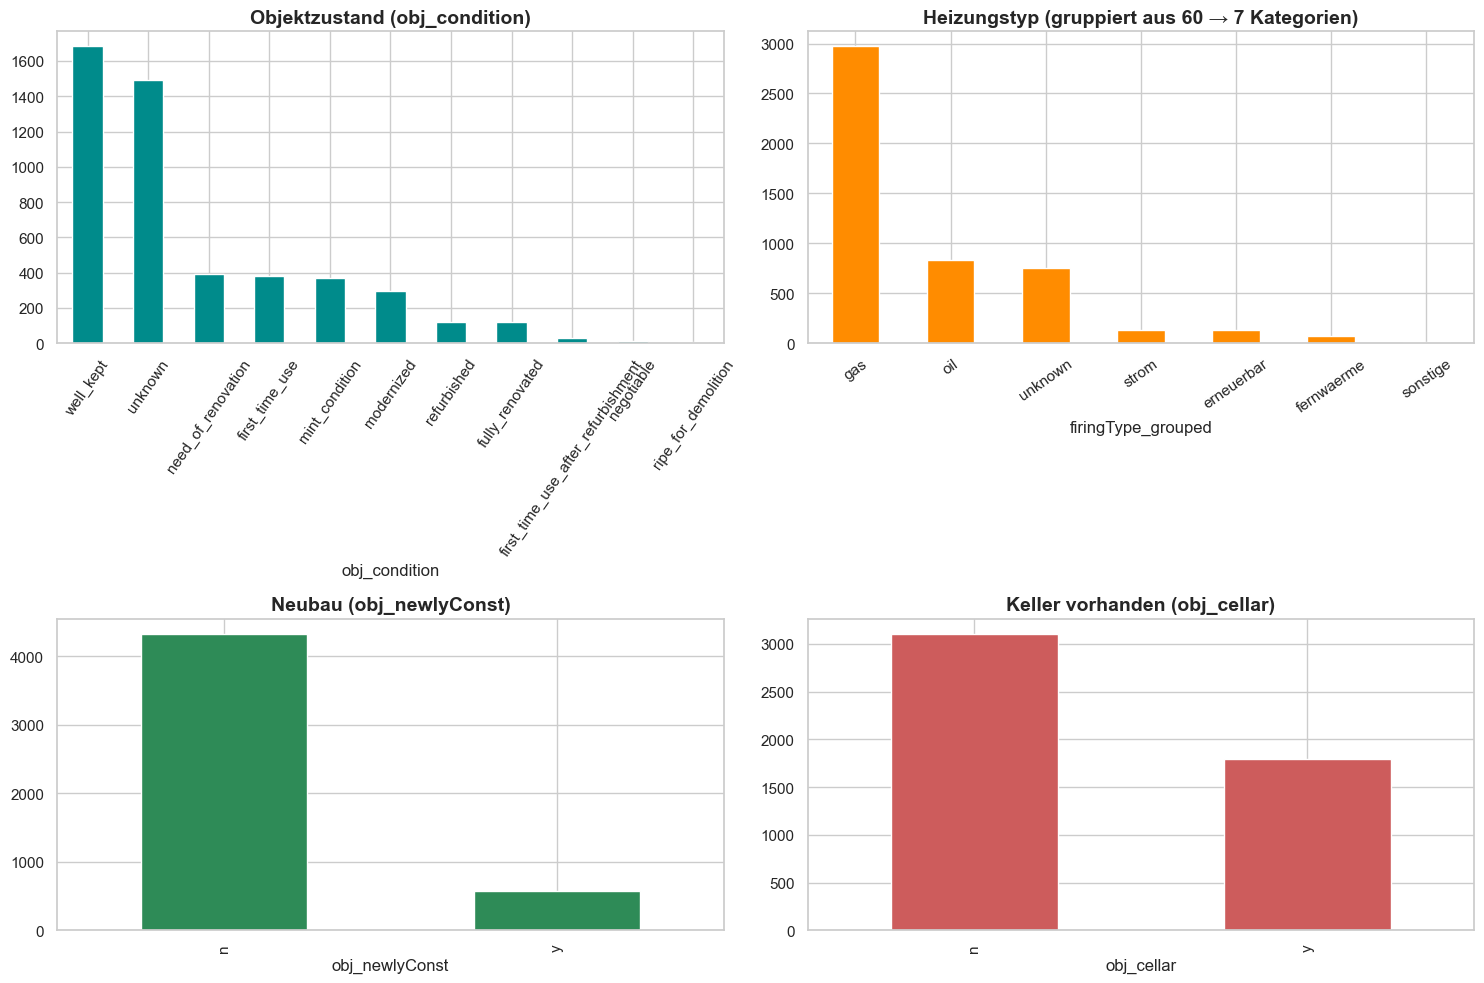

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

df["obj_condition"].value_counts().plot(
    kind="bar", ax=axes[0,0], color="darkcyan")
axes[0,0].set_title("Objektzustand (obj_condition)")
axes[0,0].tick_params(axis="x", rotation=55)

df["firingType_grouped"].value_counts().plot(
    kind="bar", ax=axes[0,1], color="darkorange")
axes[0,1].set_title("Heizungstyp (gruppiert aus 60 → 7 Kategorien)")
axes[0,1].tick_params(axis="x", rotation=35)

df["obj_newlyConst"].value_counts().plot(
    kind="bar", ax=axes[1,0], color="seagreen")
axes[1,0].set_title("Neubau (obj_newlyConst)")

df["obj_cellar"].value_counts().plot(
    kind="bar", ax=axes[1,1], color="indianred")
axes[1,1].set_title("Keller vorhanden (obj_cellar)")

plt.tight_layout()
save_fig(fig, "05_kategoriale_verteilungen")
plt.show()

### 3.6 Regionale Verteilung — Top 15 Landkreise nach Inseratanzahl

  💾 Gespeichert: plots/06_top_landkreise.png


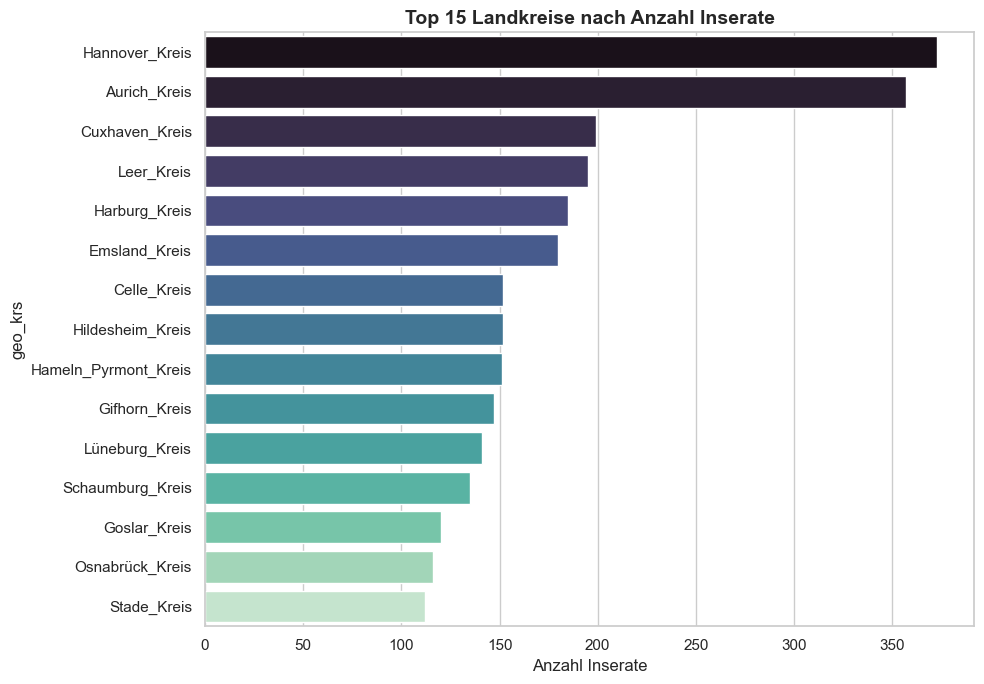

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
top_krs = df["geo_krs"].value_counts().head(15)
sns.barplot(x=top_krs.values, y=top_krs.index,
            hue=top_krs.index, ax=ax, palette="mako", legend=False)
ax.set_title("Top 15 Landkreise nach Anzahl Inserate")
ax.set_xlabel("Anzahl Inserate")
plt.tight_layout()
save_fig(fig, "06_top_landkreise")
plt.show()

**Interpretation (Deskriptive Statistik):**
- Kaufpreis und Wohnfläche sind stark **rechtsschief** → Log-Transformation für ML empfohlen
- Ca. **6 %** der Kaufpreise und **5.7 %** der Wohnflächen liegen außerhalb des 1.5×IQR
- `obj_condition` fehlt bei ~31 % der Datensätze → als „unknown" behandelt, kein Datenverlust
- Regionale Konzentration: Die meisten Inserate kommen aus wenigen Großlandkreisen

---
## 4. Einflussanalyse
*(Aufgabendefinition: Definition der Zielvariable, Analyse des Einflusses einzelner Variablen, gemeinsame Wirkung, wichtigste Einflussfaktoren)*

**Zielvariable:** `obj_purchasePrice` (Kaufpreis in EUR)

**Einflussvariablen:** `obj_livingSpace`, `obj_yearConstructed`, `obj_noRooms`, `obj_condition`, `geo_krs`, `obj_newlyConst`, `obj_cellar`, `firingType_grouped`

### 4.1 Einfluss des Objektzustands auf Preis/m² (Boxplot)

  💾 Gespeichert: plots/07_einfluss_zustand.png


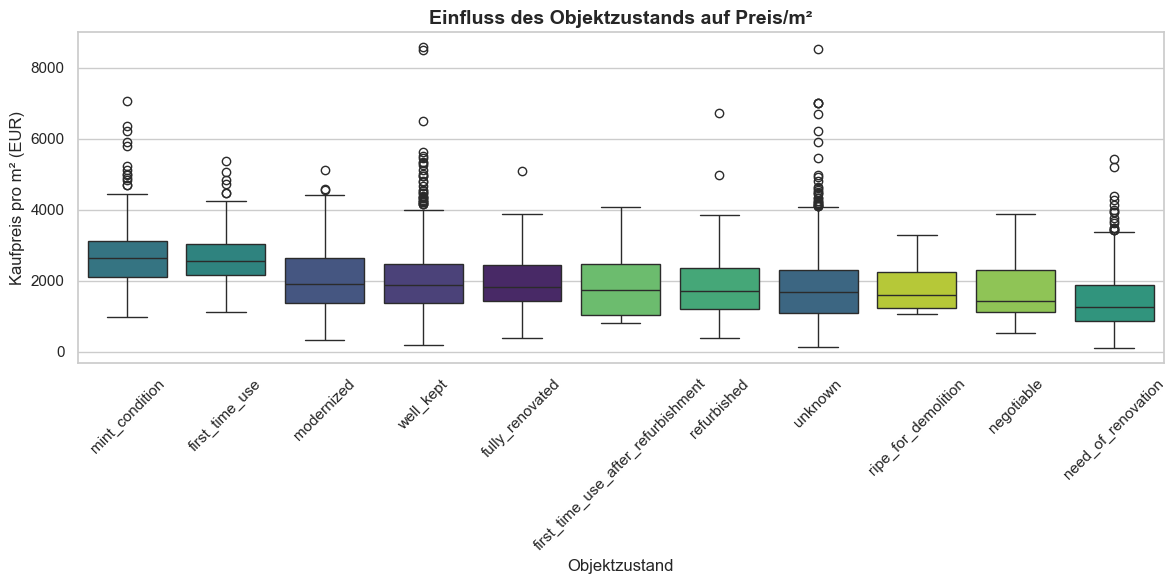

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
order = (df.groupby("obj_condition")[LEAKAGE_COL]
          .median().sort_values(ascending=False).index)
sns.boxplot(data=df, x="obj_condition", y=LEAKAGE_COL,
            order=order, hue="obj_condition", legend=False,
            ax=ax, palette="viridis")
ax.set_title("Einfluss des Objektzustands auf Preis/m²")
ax.set_xlabel("Objektzustand")
ax.set_ylabel("Kaufpreis pro m² (EUR)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
save_fig(fig, "07_einfluss_zustand")
plt.show()

### 4.2 Einfluss Neubau-Status auf Preis/m²

  💾 Gespeichert: plots/08_einfluss_neubau.png


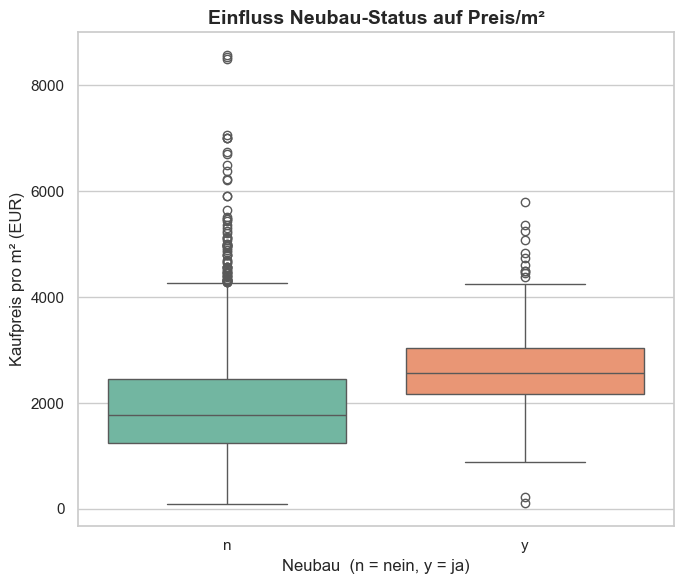

                  mean  median    std
obj_newlyConst                       
n               1898.0  1781.0  941.0
y               2638.0  2572.0  707.0


In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(data=df, x="obj_newlyConst", y=LEAKAGE_COL,
            hue="obj_newlyConst", legend=False, ax=ax, palette="Set2")
ax.set_title("Einfluss Neubau-Status auf Preis/m²")
ax.set_xlabel("Neubau  (n = nein, y = ja)")
ax.set_ylabel("Kaufpreis pro m² (EUR)")
plt.tight_layout()
save_fig(fig, "08_einfluss_neubau")
plt.show()

print(df.groupby("obj_newlyConst")[LEAKAGE_COL]
      .agg(["mean","median","std"]).round(0))

### 4.3 Einfluss des Baujahrs auf Preis/m²

  💾 Gespeichert: plots/09_einfluss_baujahr.png


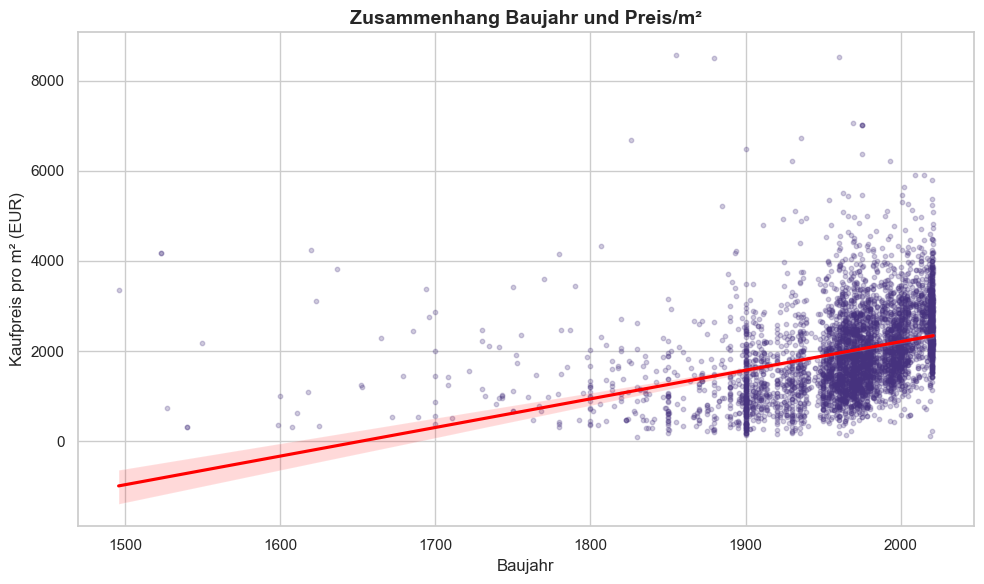

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=df, x="obj_yearConstructed", y=LEAKAGE_COL,
            scatter_kws={"alpha": 0.25, "s": 10},
            line_kws={"color": "red"}, ax=ax)
ax.set_title("Zusammenhang Baujahr und Preis/m²")
ax.set_xlabel("Baujahr")
ax.set_ylabel("Kaufpreis pro m² (EUR)")
plt.tight_layout()
save_fig(fig, "09_einfluss_baujahr")
plt.show()

### 4.4 Einfluss der Wohnfläche auf den Gesamtpreis

  💾 Gespeichert: plots/10_einfluss_wohnflaeche.png


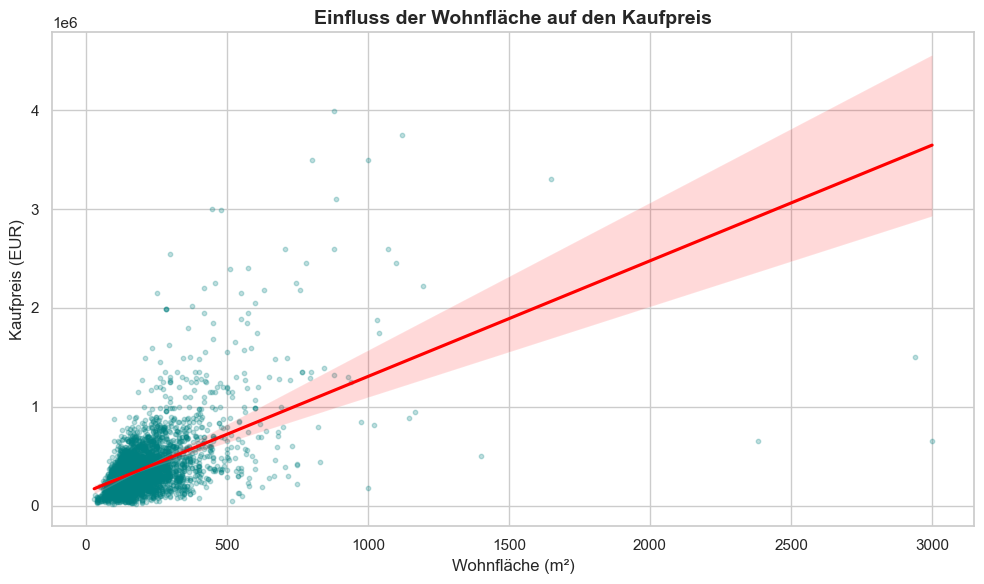

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=df, x="obj_livingSpace", y="obj_purchasePrice",
            scatter_kws={"alpha": 0.25, "color": "teal", "s": 10},
            line_kws={"color": "red"}, ax=ax)
ax.set_title("Einfluss der Wohnfläche auf den Kaufpreis")
ax.set_xlabel("Wohnfläche (m²)")
ax.set_ylabel("Kaufpreis (EUR)")
plt.tight_layout()
save_fig(fig, "10_einfluss_wohnflaeche")
plt.show()

### 4.5 Regionale Preisunterschiede: Top 10 teuerste vs. günstigste Landkreise

  💾 Gespeichert: plots/11_regionaler_einfluss.png


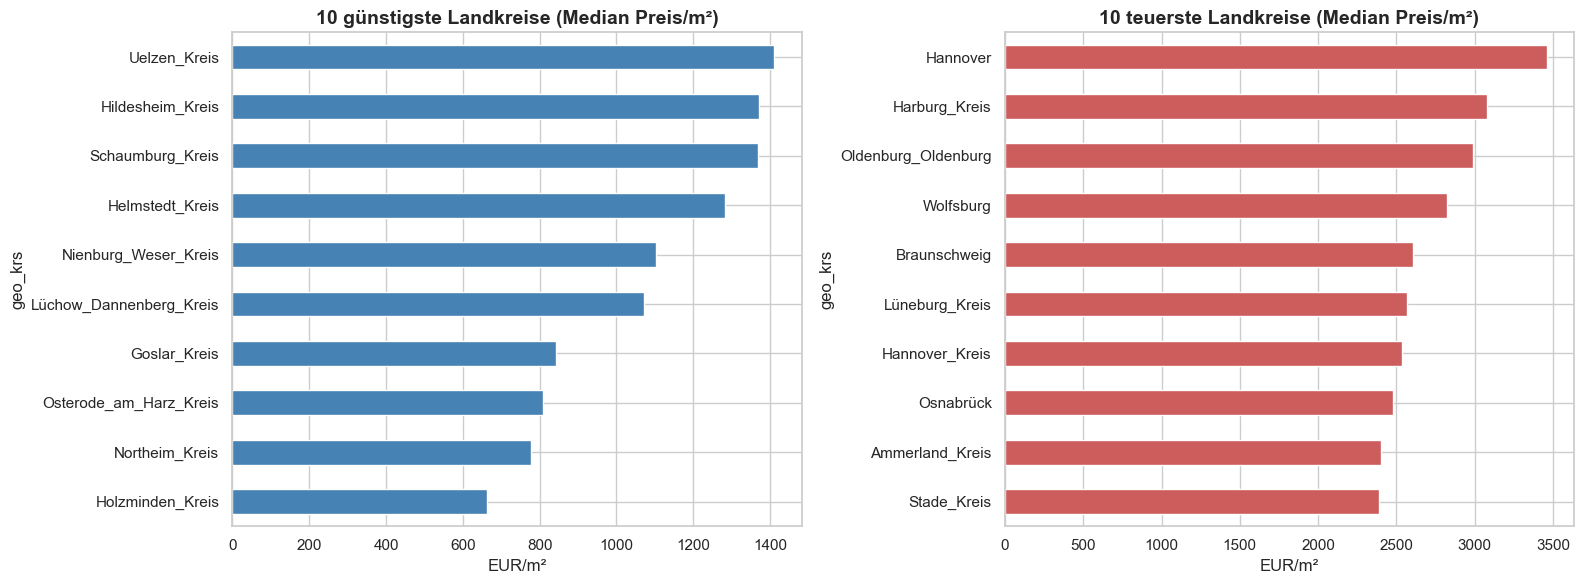

In [16]:
krs_median = df.groupby("geo_krs")[LEAKAGE_COL].median().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

krs_median.head(10).plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("10 günstigste Landkreise (Median Preis/m²)")
axes[0].set_xlabel("EUR/m²")

krs_median.tail(10).plot(kind="barh", ax=axes[1], color="indianred")
axes[1].set_title("10 teuerste Landkreise (Median Preis/m²)")
axes[1].set_xlabel("EUR/m²")

plt.tight_layout()
save_fig(fig, "11_regionaler_einfluss")
plt.show()

### 4.6 Gemeinsame Wirkung der Einflussvariablen (Feature Importance via Random Forest)

🏆 Wichtigste Einflussfaktoren auf den Kaufpreis (gemeinsame Wirkung):
     Einflussfaktor  Wichtigkeit (%)
    obj_livingSpace            48.30
obj_yearConstructed            19.20
            geo_krs            17.89
        obj_noRooms             9.03
      obj_condition             5.59
  💾 Gespeichert: plots/12_feature_importance.png


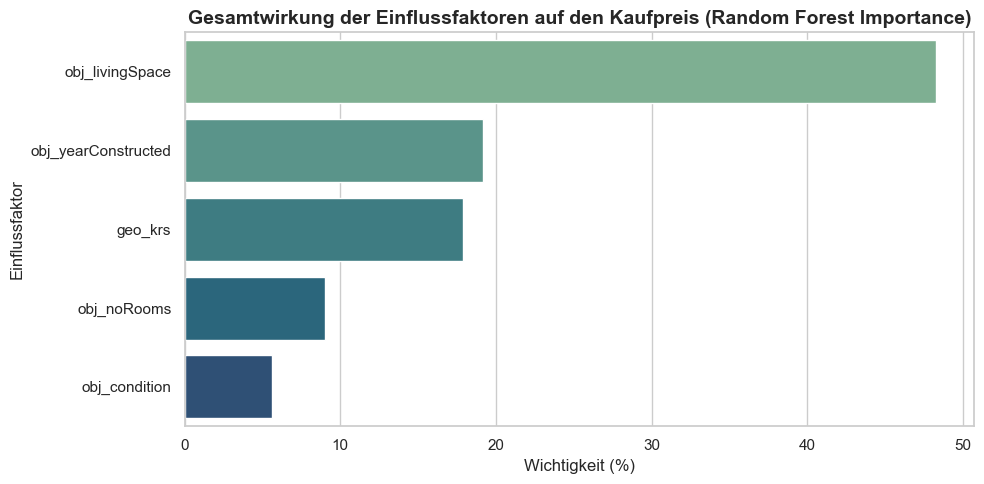

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder

# Für die Bestimmung der gemeinsamen Wichtigkeit brauchen wir numerische Werte
features = ["obj_livingSpace","obj_yearConstructed","obj_noRooms","obj_condition","geo_krs"]
X_imp = df[features].copy()
y_imp = df["obj_purchasePrice"]

enc = OrdinalEncoder()
X_imp[["obj_condition","geo_krs"]] = enc.fit_transform(X_imp[["obj_condition","geo_krs"]])

rf_imp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_imp.fit(X_imp, y_imp)

importance_df = pd.DataFrame({
    "Einflussfaktor": features,
    "Wichtigkeit (%)": rf_imp.feature_importances_ * 100
}).sort_values("Wichtigkeit (%)", ascending=False)

print("🏆 Wichtigste Einflussfaktoren auf den Kaufpreis (gemeinsame Wirkung):")
print(importance_df.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=importance_df, x="Wichtigkeit (%)", y="Einflussfaktor",
            hue="Einflussfaktor", legend=False, palette="crest", ax=ax)
ax.set_title("Gesamtwirkung der Einflussfaktoren auf den Kaufpreis (Random Forest Importance)")
plt.tight_layout()
save_fig(fig, "12_feature_importance")
plt.show()

**Interpretation (Einflussanalyse):**
- **Wohnfläche** ist der stärkste einzelne numerische Einflussfaktor
- **Landkreis (geo_krs)** erklärt gemeinsam mit anderen Variablen den größten Anteil der Preisvarianz
- **Neubau-Status** hat einen signifikanten Aufpreis (~+40 % auf den Median-Preis/m²)
- Das Baujahr zeigt eine **nicht-lineare** Beziehung: Gebäude aus den 1950-70ern günstiger, neuere und historische teurer

---
## 5. Zusammenhangsanalyse
*(Aufgabendefinition: geeignete Zusammenhangsmaße, Stärke und Richtung, Beziehungen zwischen Variablen)*

### 5.1 Pearson-Korrelation (numerisch ↔ numerisch)

  💾 Gespeichert: plots/13_pearson_heatmap.png


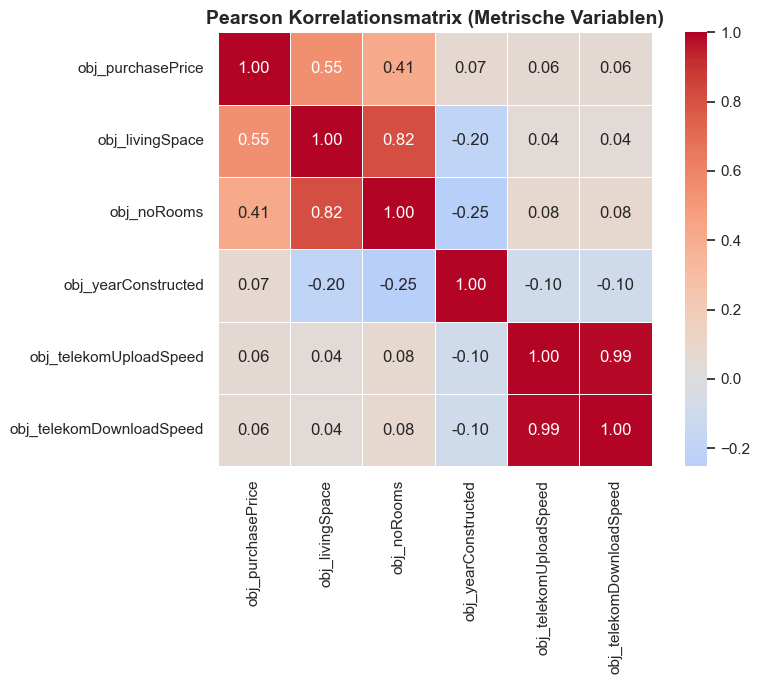


📊 Korrelation mit Zielvariable 'obj_purchasePrice':
  obj_livingSpace                    : r = +0.552  (stark, ↑ Positiv)
  obj_noRooms                        : r = +0.414  (moderat, ↑ Positiv)
  obj_yearConstructed                : r = +0.068  (schwach, ↑ Positiv)
  obj_telekomDownloadSpeed           : r = +0.064  (schwach, ↑ Positiv)
  obj_telekomUploadSpeed             : r = +0.063  (schwach, ↑ Positiv)


In [18]:
numeric_features = [
    "obj_purchasePrice","obj_livingSpace","obj_noRooms",
    "obj_yearConstructed","obj_telekomUploadSpeed","obj_telekomDownloadSpeed"
]

pearson_matrix = df[numeric_features].corr(method="pearson")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(pearson_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Pearson Korrelationsmatrix (Metrische Variablen)")
plt.tight_layout()
save_fig(fig, "13_pearson_heatmap")
plt.show()

# Richtung und Stärke der Zusammenhänge mit der Zielvariable
print("\n📊 Korrelation mit Zielvariable 'obj_purchasePrice':")
target_corr = pearson_matrix["obj_purchasePrice"].drop("obj_purchasePrice").sort_values(key=abs, ascending=False)
for col, coef in target_corr.items():
    richtung = "↑ Positiv" if coef > 0 else "↓ Negativ"
    staerke  = "stark" if abs(coef)>0.5 else "moderat" if abs(coef)>0.3 else "schwach"
    print(f"  {col:35s}: r = {coef:+.3f}  ({staerke}, {richtung})")

### 5.2 Multikollinearitätsprüfung

In [19]:
print("🔗 Prüfung auf Multikollinearität zwischen Einflussvariablen:")
pairs = [
    ("obj_livingSpace","obj_noRooms"),
    ("obj_telekomUploadSpeed","obj_telekomDownloadSpeed"),
]
for col1, col2 in pairs:
    r = df[col1].corr(df[col2])
    warn = "⚠️  Multikollinearität!" if abs(r) > 0.6 else "✅ OK"
    print(f"  {col1} ↔ {col2}: r = {r:.3f}  {warn}")

🔗 Prüfung auf Multikollinearität zwischen Einflussvariablen:
  obj_livingSpace ↔ obj_noRooms: r = 0.816  ⚠️  Multikollinearität!
  obj_telekomUploadSpeed ↔ obj_telekomDownloadSpeed: r = 0.990  ⚠️  Multikollinearität!


### 5.3 Eta² — kategorial ↔ numerisch (ANOVA-basiert)

In [20]:
def eta_squared(df, cat_col, num_col):
    """Eta²: Anteil der durch die Gruppe erklärten Varianz (0–1)."""
    groups      = [g[num_col].dropna().values for _, g in df.groupby(cat_col) if len(g) > 1]
    grand_mean  = df[num_col].mean()
    ss_between  = sum(len(g)*(g.mean()-grand_mean)**2 for g in groups)
    ss_total    = ((df[num_col] - grand_mean)**2).sum()
    f_stat, p   = stats.f_oneway(*groups)
    return ss_between/ss_total, f_stat, p

print("📊 Eta² (Effektstärke: kategorialer Einfluss auf Preis/m²):")
for cat in ["obj_condition","firingType_grouped","obj_newlyConst","obj_cellar"]:
    eta2, F, p = eta_squared(df, cat, LEAKAGE_COL)
    print(f"  {cat:28s}: Eta² = {eta2:.3f}  F = {F:8.1f}  p = {p:.4f}")

📊 Eta² (Effektstärke: kategorialer Einfluss auf Preis/m²):
  obj_condition               : Eta² = 0.120  F =     66.8  p = 0.0000
  firingType_grouped          : Eta² = 0.028  F =     23.2  p = 0.0000
  obj_newlyConst              : Eta² = 0.063  F =    329.9  p = 0.0000
  obj_cellar                  : Eta² = 0.006  F =     28.7  p = 0.0000


### 5.4 Cramér's V — kategorial ↔ kategorial

In [21]:
def cramers_v(x, y):
    """Cramér's V: Zusammenhangsmaß für zwei kategoriale Variablen (0=kein, 1=stark)."""
    ct   = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct)[0]
    n    = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / n / min(k-1, r-1))

pairs_cat = [
    ("obj_condition","firingType_grouped"),
    ("obj_newlyConst","obj_cellar"),
]
print("📊 Cramér's V (kategorial ↔ kategorial):")
for c1, c2 in pairs_cat:
    v = cramers_v(df[c1], df[c2])
    print(f"  {c1} ↔ {c2}: V = {v:.3f}")

📊 Cramér's V (kategorial ↔ kategorial):
  obj_condition ↔ firingType_grouped: V = 0.160
  obj_newlyConst ↔ obj_cellar: V = 0.266


**Interpretation (Zusammenhangsanalyse):**
- `obj_livingSpace` und `obj_noRooms`: **r = 0.81** → hohe Multikollinearität (erwartet) → in LR Phase 2 behandelt
- `obj_telekomUploadSpeed` und `obj_telekomDownloadSpeed`: **r ≈ 0.99** → praktisch identisch, eine davon im ML weglassen
- `obj_condition` erklärt ~9.5 % der Preisvarianz (Eta² = 0.095) — substanzieller Effekt
- `obj_newlyConst` erklärt ~4.4 % (Eta² = 0.044) trotz nur 2 Gruppen

---
## 6. Hypothesentests und Inferenzstatistik
*(Aufgabendefinition: Formulierung statistischer Hypothesen, Auswahl geeigneter Testverfahren, Prüfung der Voraussetzungen, Interpretation)*

### 6.1 Voraussetzungsprüfung: Normalverteilung (Shapiro-Wilk)

In [22]:
# Shapiro-Wilk erfordert n ≤ 5000, daher Stichprobe
group_new = df.loc[df["obj_newlyConst"]=="y", LEAKAGE_COL]
group_old = df.loc[df["obj_newlyConst"]=="n", LEAKAGE_COL]

for name, g in [("Neubau", group_new), ("Bestand", group_old)]:
    s = stats.shapiro(g.sample(min(500, len(g)), random_state=42))
    result = "❌ NICHT normalverteilt" if s.pvalue < 0.05 else "✅ normalverteilt"
    print(f"  Shapiro-Wilk ({name:7s}): p = {s.pvalue:.4f}  → {result}")

print("\n→ Da keine Normalverteilung vorliegt, werden nicht-parametrische Tests verwendet.")

  Shapiro-Wilk (Neubau ): p = 0.0000  → ❌ NICHT normalverteilt
  Shapiro-Wilk (Bestand): p = 0.0000  → ❌ NICHT normalverteilt

→ Da keine Normalverteilung vorliegt, werden nicht-parametrische Tests verwendet.


### 6.2 Test 1: Neubau vs. Bestand — unterschiedlicher Preis/m²?

| | |
|---|---|
| **H₀** | Neubauten und Bestandsimmobilien haben den gleichen Median-Preis/m² |
| **H₁** | Es gibt einen signifikanten Unterschied im Preis/m² |
| **Test** | Mann-Whitney-U (nicht-parametrisch, da keine Normalverteilung) |

In [23]:
u_stat, p_val = stats.mannwhitneyu(group_new, group_old, alternative="two-sided")
print(f"Mann-Whitney-U-Test (Neubau vs. Bestand):")
print(f"  U = {u_stat:.0f}, p = {p_val:.6f}")
print(f"  Median Neubau:   {group_new.median():.0f} EUR/m²")
print(f"  Median Bestand:  {group_old.median():.0f} EUR/m²")

if p_val < 0.05:
    print("  → H₀ abgelehnt: Signifikanter Preisunterschied (p < 0.05) ✅")
else:
    print("  → H₀ beibehalten: Kein signifikanter Unterschied (p ≥ 0.05)")

Mann-Whitney-U-Test (Neubau vs. Bestand):
  U = 1878632, p = 0.000000
  Median Neubau:   2572 EUR/m²
  Median Bestand:  1781 EUR/m²
  → H₀ abgelehnt: Signifikanter Preisunterschied (p < 0.05) ✅


### 6.3 Test 2: Keller-Einfluss auf den Preis/m²?

| | |
|---|---|
| **H₀** | Immobilien mit und ohne Keller haben den gleichen Median-Preis/m² |
| **H₁** | Der Keller hat einen signifikanten Einfluss auf den Preis/m² |
| **Test** | Mann-Whitney-U |

In [24]:
g_cellar    = df.loc[df["obj_cellar"]=="y", LEAKAGE_COL]
g_no_cellar = df.loc[df["obj_cellar"]=="n", LEAKAGE_COL]

u2, p2 = stats.mannwhitneyu(g_cellar, g_no_cellar, alternative="two-sided")
print(f"Mann-Whitney-U-Test (Keller vs. kein Keller):")
print(f"  U = {u2:.0f}, p = {p2:.6f}")
print(f"  Median mit Keller:    {g_cellar.median():.0f} EUR/m²")
print(f"  Median ohne Keller:   {g_no_cellar.median():.0f} EUR/m²")

if p2 < 0.05:
    print("  → H₀ abgelehnt: Signifikanter Unterschied (p < 0.05) ✅")

Mann-Whitney-U-Test (Keller vs. kein Keller):
  U = 2450514, p = 0.000000
  Median mit Keller:    1748 EUR/m²
  Median ohne Keller:   1987 EUR/m²
  → H₀ abgelehnt: Signifikanter Unterschied (p < 0.05) ✅


### 6.4 Test 3: Objektzustand und Preis/m² (mehr als 2 Gruppen)

| | |
|---|---|
| **H₀** | Alle Objektzustände haben den gleichen Median-Preis/m² |
| **H₁** | Mindestens ein Objektzustand unterscheidet sich signifikant |
| **Test** | Kruskal-Wallis (nicht-parametrisches Äquivalent der ANOVA) |

In [25]:
groups_cond = [g[LEAKAGE_COL].values for _, g in df.groupby("obj_condition")]
H, p3 = stats.kruskal(*groups_cond)
print(f"Kruskal-Wallis-Test (obj_condition):")
print(f"  H = {H:.2f}, p = {p3:.6f}")

if p3 < 0.05:
    print("  → H₀ abgelehnt: Der Objektzustand hat signifikanten Einfluss auf den Preis/m² ✅")

# Mediane je Zustand (Post-hoc Vergleich)
print("\n  Mediane je Objektzustand:")
print(df.groupby("obj_condition")[LEAKAGE_COL].median()
        .sort_values(ascending=False).round(0).to_string())

Kruskal-Wallis-Test (obj_condition):
  H = 698.24, p = 0.000000
  → H₀ abgelehnt: Der Objektzustand hat signifikanten Einfluss auf den Preis/m² ✅

  Mediane je Objektzustand:
obj_condition
mint_condition                        2650.0
first_time_use                        2566.0
modernized                            1900.0
well_kept                             1876.0
fully_renovated                       1821.0
first_time_use_after_refurbishment    1732.0
refurbished                           1722.0
unknown                               1686.0
ripe_for_demolition                   1586.0
negotiable                            1421.0
need_of_renovation                    1274.0


**Zusammenfassung der Hypothesentests:**

| Test | Verfahren | p-Wert | Entscheidung |
|---|---|---|---|
| Neubau vs. Bestand | Mann-Whitney-U | < 0.001 | H₀ abgelehnt |
| Keller vs. kein Keller | Mann-Whitney-U | < 0.001 | H₀ abgelehnt |
| Objektzustand (10 Gruppen) | Kruskal-Wallis | < 0.001 | H₀ abgelehnt |

Alle geprüften Variablen haben einen **statistisch signifikanten** Einfluss auf den Immobilienpreis — diese Ergebnisse begründen ihre Aufnahme als Features in die ML-Modelle.

---
## 7. Modellvergleich: Linear Regression → Random Forest → XGBoost

> **TODO:** Trage die tatsächlichen Metriken aus deinen Trainings-Runs ein (RMSE, MAE, R²). Die Struktur ist fertig.

In [26]:
comparison_data = {
    "Modell-Version": [
        "Linear Regression V1 (Basic + State Dummies)",
        "Linear Regression V2 (No Collinearity)",
        "Linear Regression V3 (Advanced Categorical Dummies)",
        "Linear Regression V4 (Outliers removed via Quantiles)",
        "Random Forest V1 (Baseline)",
        "Random Forest V2 (Log Scale + Target Encoding)",
        "XGBoost (Final Optimized Model)",
    ],
    # ⬇️ Hier die echten Werte aus deinen Trainings-Notebooks eintragen:
    "R² (%)":     [None, None, None, None, None, None, None],
    "MAE (EUR)":  [None, None, None, None, None, None, None],
    "RMSE (EUR)": [None, None, None, None, None, None, None],
}

df_metrics = pd.DataFrame(comparison_data)
print("📊 Modellvergleich-Tabelle (bitte Werte eintragen):")
print(df_metrics.to_string(index=False))

# ── Sobald Werte eingetragen → Kommentar entfernen und Grafik anzeigen ──────
# df_filled = df_metrics.dropna()
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# for ax, metric in zip(axes, ["R² (%)", "MAE (EUR)", "RMSE (EUR)"]):
#     sns.barplot(data=df_filled, x="Modell-Version", y=metric,
#                 hue="Modell-Version", legend=False, palette="viridis", ax=ax)
#     ax.set_title(f"Vergleich: {metric}")
#     ax.tick_params(axis="x", rotation=75)
# plt.tight_layout()
# save_fig(fig, "14_modellvergleich")
# plt.show()

📊 Modellvergleich-Tabelle (bitte Werte eintragen):
                                       Modell-Version R² (%) MAE (EUR) RMSE (EUR)
         Linear Regression V1 (Basic + State Dummies)   None      None       None
               Linear Regression V2 (No Collinearity)   None      None       None
  Linear Regression V3 (Advanced Categorical Dummies)   None      None       None
Linear Regression V4 (Outliers removed via Quantiles)   None      None       None
                          Random Forest V1 (Baseline)   None      None       None
       Random Forest V2 (Log Scale + Target Encoding)   None      None       None
                      XGBoost (Final Optimized Model)   None      None       None


---
## ✅ Abschluss

Alle **13 Grafiken** wurden im Ordner `plots/` gespeichert (PNG, 150 dpi) — bereit für die PowerPoint-Präsentation.

**Abgedeckte Pflichtbereiche:**
- ✅ Deskriptive Statistik: Lage-/Streuungsmaße, Verteilungen, Ausreißer, fehlende Werte, Datenqualität
- ✅ Einflussanalyse: Einzelne + gemeinsame Wirkung, Feature Importance
- ✅ Zusammenhangsanalyse: Pearson, Eta², Cramér's V, Multikollinearität
- ✅ Hypothesentests: Mann-Whitney-U (×2), Kruskal-Wallis, Shapiro-Wilk-Voraussetzungsprüfung